In [1]:
# import python libraries

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib

In [2]:
# some values used for calculations

k = 8.61733e-5; # boltzmann constant in eV/K
TK = 1150+273; # equilibrium temp in K
TC = TK-273; # equilibrium temp in C
TQK = 500+273;# quenched temp in K
TQC = TQK-273; # quenched temp in C
a = np.logspace(-20,5,200); # oxygen partial pressure range
# print(
#     f'a[154] = {a[154]:.2} atm'
# ) # pO2~0.21 atm

In [3]:
# Equilibrium defect reaction constants

KR = 1.06E71*np.exp(-5.69/(k*TK))
Ki = 8.55E44*np.exp(-2.91/(k*TK))
KiQ = 8.55E44*np.exp(-2.91/(k*TQK))
KS = (3.4E105)*np.exp(-2.795/(k*TK))

# Lee, Soonil, Clive A. Randall, and Zi‐Kui Liu. "Comprehensive Linkage of Defect and Phase Equilibria through Ferroelectric Transition Behavior in BaTiO3‐Based Dielectrics: Part 1. Defect Energies Under Ambient Air Conditions." Journal of the American Ceramic Society 91, no. 6 (2008): 1748-1752.
KPSB = (1.15E22)**2*np.exp(10.15)*np.exp(-2.32/(k*TK)) # partial Schottky reaction on Ti-rich; [VBa2-] is fixed

# Hagemann, H‐J., and D. Hennings. "Reversible weight change of acceptor‐doped BaTiO3." Journal of the American Ceramic Society 64, no. 10 (1981): 590-594.
KMn43 = 2*2.0E22*np.exp(-(3.12-1.28)/(k*TK))
KMn43Q = 2*2.0E22*np.exp(-(3.12-1.28)/(k*TQK))
KMn32 = 1/2*2.0E22*np.exp(-(3.12-1.87)/(k*TK))
KMn32Q = 1/2*2.0E22*np.exp(-(3.12-1.87)/(k*TQK))

print(
    f'at T = {TC} \u00B0C\n'
    f'KS = {KS:.2e}\n'
    f'KPSB = {KPSB:.2e}\n'
    f'Ki = {Ki:.2e}\n'
    f'KiQ = {KiQ:.2e}\n'
    f'KR = {KR:.2e}\n'
    f'KMn43 = {KMn43:.2e}\n'
    f'KMn43Q = {KMn43Q:.2e}\n'
    f'KMn32 = {KMn32:.2e}\n'
    f'KMn32Q = {KMn32Q:.2e}'
)


at T = 1150 °C
KS = 4.29e+95
KPSB = 2.06e+40
Ki = 4.22e+34
KiQ = 9.11e+25
KR = 7.47e+50
KMn43 = 1.22e+16
KMn43Q = 4.03e+10
KMn32 = 3.74e+17
KMn32Q = 7.08e+13


In [4]:
# empty lists for each defect concentration; will be filled later
# Mn doped & A/B = 1.000 / 0.999 / 0.994 & high T eq / low T quenched

CVO2_Mn_1000e = np.zeros(len(a))
CVO2_Mn_1000q = np.zeros(len(a))
CVO2_Mn_999e = np.zeros(len(a))
CVO2_Mn_999q = np.zeros(len(a))
CVO2_Mn_994e = np.zeros(len(a))
CVO2_Mn_994q = np.zeros(len(a))

CVTi4_Mn_1000e = np.zeros(len(a))
CVTi4_Mn_1000q = np.zeros(len(a))
CVTi4_Mn_999e = np.zeros(len(a))
CVTi4_Mn_999q = np.zeros(len(a))
CVTi4_Mn_994e = np.zeros(len(a))
CVTi4_Mn_994q = np.zeros(len(a))

CVBa2_Mn_1000e = np.zeros(len(a))
CVBa2_Mn_1000q = np.zeros(len(a))
CVBa2_Mn_999e = np.zeros(len(a))
CVBa2_Mn_999q = np.zeros(len(a))
CVBa2_Mn_994e = np.zeros(len(a))
CVBa2_Mn_994q = np.zeros(len(a))

n_Mn_1000e = np.zeros(len(a))
n_Mn_1000q = np.zeros(len(a))
n_Mn_999e = np.zeros(len(a))
n_Mn_999q = np.zeros(len(a))
n_Mn_994e = np.zeros(len(a))
n_Mn_994q = np.zeros(len(a))

p_Mn_1000e = np.zeros(len(a))
p_Mn_1000q = np.zeros(len(a))
p_Mn_999e = np.zeros(len(a))
p_Mn_999q = np.zeros(len(a))
p_Mn_994e = np.zeros(len(a))
p_Mn_994q = np.zeros(len(a))

CMn0_Mn_1000e = np.zeros(len(a))
CMn1_Mn_1000e = np.zeros(len(a))
CMn2_Mn_1000e = np.zeros(len(a))

CMn0_Mn_1000q = np.zeros(len(a))
CMn1_Mn_1000q = np.zeros(len(a))
CMn2_Mn_1000q = np.zeros(len(a))

CMn0_Mn_999e = np.zeros(len(a))
CMn1_Mn_999e = np.zeros(len(a))
CMn2_Mn_999e = np.zeros(len(a))

CMn0_Mn_999q = np.zeros(len(a))
CMn1_Mn_999q = np.zeros(len(a))
CMn2_Mn_999q = np.zeros(len(a))

CMn0_Mn_994e = np.zeros(len(a))
CMn1_Mn_994e = np.zeros(len(a))
CMn2_Mn_994e = np.zeros(len(a))

CMn0_Mn_994q = np.zeros(len(a))
CMn1_Mn_994q = np.zeros(len(a))
CMn2_Mn_994q = np.zeros(len(a))

Mn doped & A/B = 1.0 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 7.69e+15
p = 5.49e+18
[VO2+] = 2.68e+19
[VBa2-] = 4.72e+18
[VTi4-] = 4.72e+18
[Mnt] = 7.70e+19
[Mn0] = 4.68e+19
[Mn1-] = 2.96e+19
[Mn2-] = 6.08e+17



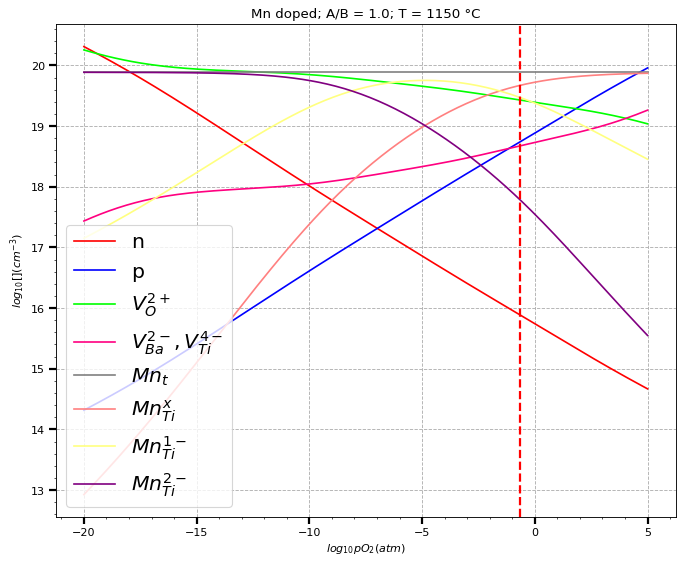

In [5]:
"""
[13] Mn doped & A/B = 1.000 & high T eq

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
ratio = 1.000
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) + (CMnt/(KMn43/x + 1 + x/KMn32))*(1 + 2*x/KMn32) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30)
    
    n_Mn_1000e[i] = np.array(sol1).astype(np.float64)
    p_Mn_1000e[i] = Ki/n_Mn_1000e[i]
    CVO2_Mn_1000e[i] = KR/((n_Mn_1000e[i]**2)*(y**(1/2)))
    CVTi4_Mn_1000e[i] = (KS/(KR**3))**(1/2)*(n_Mn_1000e[i]**3)*(y**(3/4))
    CVBa2_Mn_1000e[i] = CVTi4_Mn_1000e[i]
    CMn1_Mn_1000e[i] = CMnt/(KMn43/n_Mn_1000e[i] + 1 + n_Mn_1000e[i]/KMn32)
    CMn2_Mn_1000e[i] = CMn1_Mn_1000e[i]*n_Mn_1000e[i]/KMn32
    CMn0_Mn_1000e[i] = CMnt - CMn1_Mn_1000e[i] - CMn2_Mn_1000e[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_Mn_1000e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_Mn_1000e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_Mn_1000e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_Mn_1000e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_1000e+CMn2_Mn_1000e+CMn0_Mn_1000e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_Mn_1000e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_1000e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_Mn_1000e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_Mn_1000e[154]:.2e}\n'
    f'p = {p_Mn_1000e[154]:.2e}\n'
    f'[VO2+] = {CVO2_Mn_1000e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_Mn_1000e[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_Mn_1000e[154]:.2e}\n'
    f'[Mnt] = {CMn1_Mn_1000e[154]+CMn2_Mn_1000e[154]+CMn0_Mn_1000e[154]:.2e}\n'
    f'[Mn0] = {CMn0_Mn_1000e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_Mn_1000e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_Mn_1000e[154]:.2e}'
)

Mn doped & A/B = 0.999 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 7.54e+15
p = 5.61e+18
[VO2+] = 2.79e+19
[VBa2-] = 1.55e+19
[Mnt] = 7.70e+19
[Mn0] = 4.72e+19
[Mn1-] = 2.92e+19
[Mn2-] = 5.89e+17



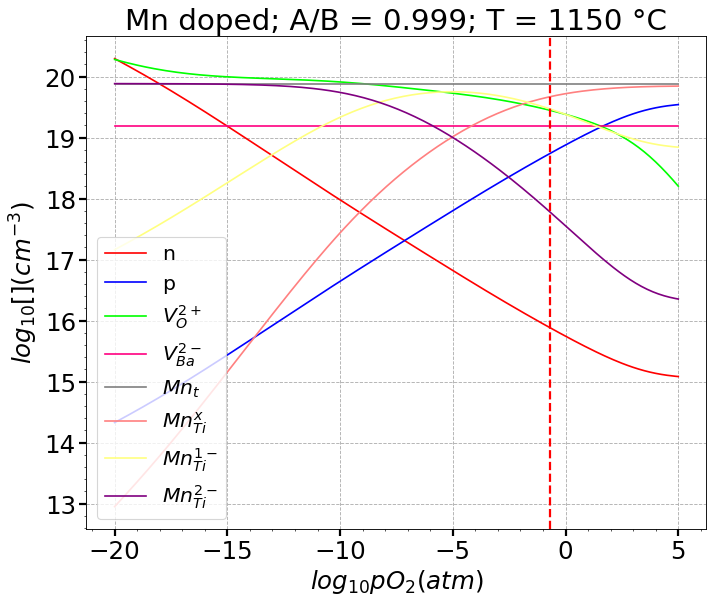

In [6]:
"""
[14] Mn doped & A/B = 0.999 & high T eq

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3
"""
ratio = 0.999
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*(1 - ratio)*1.55E22 + (CMnt/(KMn43/x + 1 + x/KMn32))*(1 + 2*x/KMn32) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30)
    
    n_Mn_999e[i] = np.array(sol1).astype(np.float64)
    p_Mn_999e[i] = Ki/n_Mn_999e[i]
    CVO2_Mn_999e[i] = KR/((n_Mn_999e[i]**2)*(y**(1/2)))
    CVBa2_Mn_999e[i] = (1 - ratio)*1.55E22
    CMn1_Mn_999e[i] = CMnt/(KMn43/n_Mn_999e[i] + 1 + n_Mn_999e[i]/KMn32)
    CMn2_Mn_999e[i] = CMn1_Mn_999e[i]*n_Mn_999e[i]/KMn32
    CMn0_Mn_999e[i] = CMnt - CMn1_Mn_999e[i] - CMn2_Mn_999e[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_Mn_999e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_Mn_999e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_Mn_999e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_Mn_999e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_999e+CMn2_Mn_999e+CMn0_Mn_999e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_Mn_999e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_999e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_Mn_999e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_Mn_999e[154]:.2e}\n'
    f'p = {p_Mn_999e[154]:.2e}\n'
    f'[VO2+] = {CVO2_Mn_999e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_Mn_999e[154]:.2e}\n'
    f'[Mnt] = {CMn1_Mn_999e[154]+CMn2_Mn_999e[154]+CMn0_Mn_999e[154]:.2e}\n'
    f'[Mn0] = {CMn0_Mn_999e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_Mn_999e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_Mn_999e[154]:.2e}'
)

Mn doped & A/B = 0.994 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 4.03e+15
p = 1.05e+19
[VO2+] = 9.75e+19
[VBa2-] = 9.30e+19
[Mnt] = 7.70e+19
[Mn0] = 5.77e+19
[Mn1-] = 1.91e+19
[Mn2-] = 2.06e+17



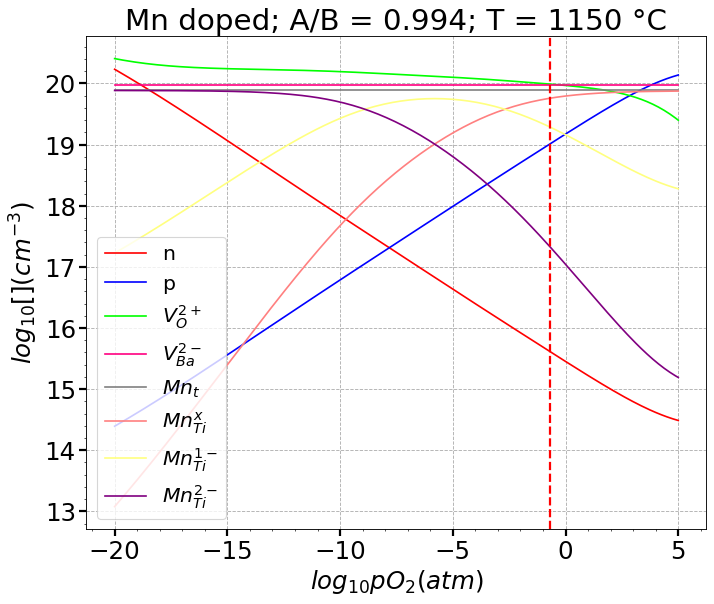

In [7]:
"""
[15] Mn doped & A/B = 0.994 & high T eq

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3
"""
ratio = 0.994
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*(1 - ratio)*1.55E22 + (CMnt/(KMn43/x + 1 + x/KMn32))*(1 + 2*x/KMn32) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30)
    
    n_Mn_994e[i] = np.array(sol1).astype(np.float64)
    p_Mn_994e[i] = Ki/n_Mn_994e[i]
    CVO2_Mn_994e[i] = KR/((n_Mn_994e[i]**2)*(y**(1/2)))
    CVBa2_Mn_994e[i] = (1 - ratio)*1.55E22
    CMn1_Mn_994e[i] = CMnt/(KMn43/n_Mn_994e[i] + 1 + n_Mn_994e[i]/KMn32)
    CMn2_Mn_994e[i] = CMn1_Mn_994e[i]*n_Mn_994e[i]/KMn32
    CMn0_Mn_994e[i] = CMnt - CMn1_Mn_994e[i] - CMn2_Mn_994e[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_Mn_994e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_Mn_994e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_Mn_994e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_Mn_994e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_994e+CMn2_Mn_994e+CMn0_Mn_994e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_Mn_994e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_994e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_Mn_994e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_Mn_994e[154]:.2e}\n'
    f'p = {p_Mn_994e[154]:.2e}\n'
    f'[VO2+] = {CVO2_Mn_994e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_Mn_994e[154]:.2e}\n'
    f'[Mnt] = {CMn1_Mn_994e[154]+CMn2_Mn_994e[154]+CMn0_Mn_994e[154]:.2e}\n'
    f'[Mn0] = {CMn0_Mn_994e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_Mn_994e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_Mn_994e[154]:.2e}'
)

/tmp/ipykernel_1441/4153547557.py:39: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_Mn_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


Mn doped & A/B = 1.0 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 1.97e+10
p = 4.62e+15
[VO2+] = 2.68e+19
[VBa2-] = 4.72e+18
[VTi4-] = 4.72e+18
[Mnt] = 7.70e+19
[Mn0] = 5.17e+19
[Mn1-] = 2.53e+19
[Mn2-] = 7.04e+15



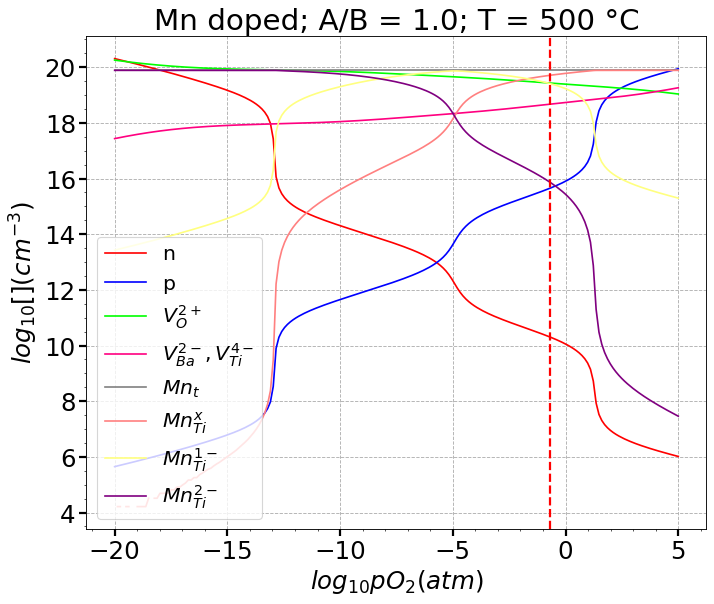

In [8]:
"""
[16] Mn doped & A/B = 1.000 & low T quenched

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 1.000
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_Mn_1000e[i] + 4*CVTi4_Mn_1000e[i] + (CMnt/(KMn43Q/x + 1 + x/KMn32Q))*(1 + 2*x/KMn32Q) - (KiQ/x) - 2*CVO2_Mn_1000e[i])
    sol1 = brentq(f,1,1E30)
    
    n_Mn_1000q[i] = np.array(sol1).astype(np.float64)
    p_Mn_1000q[i] = KiQ/n_Mn_1000q[i]
    CVO2_Mn_1000q[i] = CVO2_Mn_1000e[i]
    CVTi4_Mn_1000q[i] = CVTi4_Mn_1000e[i]
    CVBa2_Mn_1000q[i] = CVBa2_Mn_1000e[i]
    CMn1_Mn_1000q[i] = CMnt/(KMn43Q/n_Mn_1000q[i] + 1 + n_Mn_1000q[i]/KMn32Q)
    CMn2_Mn_1000q[i] = CMn1_Mn_1000q[i]*n_Mn_1000q[i]/KMn32Q
    CMn0_Mn_1000q[i] = CMnt - CMn1_Mn_1000q[i] - CMn2_Mn_1000q[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_Mn_1000q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_Mn_1000q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_Mn_1000q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_Mn_1000q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_1000q+CMn2_Mn_1000q+CMn0_Mn_1000q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_Mn_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_1000q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_Mn_1000q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_Mn_1000q[154]:.2e}\n'
    f'p = {p_Mn_1000q[154]:.2e}\n'
    f'[VO2+] = {CVO2_Mn_1000q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_Mn_1000q[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_Mn_1000q[154]:.2e}\n'
    f'[Mnt] = {CMn1_Mn_1000q[154]+CMn2_Mn_1000q[154]+CMn0_Mn_1000q[154]:.2e}\n'
    f'[Mn0] = {CMn0_Mn_1000q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_Mn_1000q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_Mn_1000q[154]:.2e}'
)

/tmp/ipykernel_1441/1455516419.py:38: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_Mn_999q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
/tmp/ipykernel_1441/1455516419.py:38: RuntimeWarning: invalid value encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_Mn_999q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


Mn doped & A/B = 0.999 & T = 500 °C
at pO2 ~ 0.21 atm
n = 1.92e+10
p = 4.76e+15
[VO2+] = 2.79e+19
[VBa2-] = 1.55e+19
[Mnt] = 7.70e+19
[Mn0] = 5.22e+19
[Mn1-] = 2.48e+19
[Mn2-] = 6.70e+15



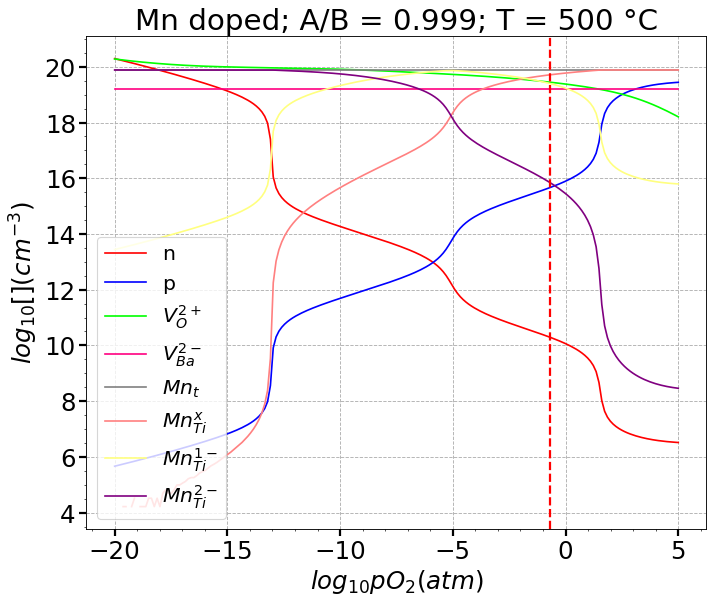

In [10]:
"""
[17] Mn doped & A/B = 0.999 & low T quenched

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3 & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 0.999
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_Mn_999e[i] + (CMnt/(KMn43Q/x + 1 + x/KMn32Q))*(1 + 2*x/KMn32Q) - (KiQ/x) - 2*CVO2_Mn_999e[i])
    sol1 = brentq(f,1,1E30)
    
    n_Mn_999q[i] = np.array(sol1).astype(np.float64)
    p_Mn_999q[i] = KiQ/n_Mn_999q[i]
    CVO2_Mn_999q[i] = CVO2_Mn_999e[i]
    CVBa2_Mn_999q[i] = CVBa2_Mn_999e[i]
    CMn1_Mn_999q[i] = CMnt/(KMn43Q/n_Mn_999q[i] + 1 + n_Mn_999q[i]/KMn32Q)
    CMn2_Mn_999q[i] = CMn1_Mn_999q[i]*n_Mn_999q[i]/KMn32Q
    CMn0_Mn_999q[i] = CMnt - CMn1_Mn_999q[i] - CMn2_Mn_999q[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_Mn_999q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_Mn_999q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_Mn_999q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_Mn_999q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_999q+CMn2_Mn_999q+CMn0_Mn_999q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_Mn_999q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_999q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_Mn_999q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_Mn_999q[154]:.2e}\n'
    f'p = {p_Mn_999q[154]:.2e}\n'
    f'[VO2+] = {CVO2_Mn_999q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_Mn_999q[154]:.2e}\n'
    f'[Mnt] = {CMn1_Mn_999q[154]+CMn2_Mn_999q[154]+CMn0_Mn_999q[154]:.2e}\n'
    f'[Mn0] = {CMn0_Mn_999q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_Mn_999q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_Mn_999q[154]:.2e}'
)

/tmp/ipykernel_1441/2936542381.py:38: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_Mn_994q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


Mn doped & A/B = 0.994 & T = 500 °C
at pO2 ~ 0.21 atm
n = 5.38e+09
p = 1.69e+16
[VO2+] = 9.75e+19
[VBa2-] = 9.30e+19
[Mnt] = 7.70e+19
[Mn0] = 6.79e+19
[Mn1-] = 9.06e+18
[Mn2-] = 6.87e+14



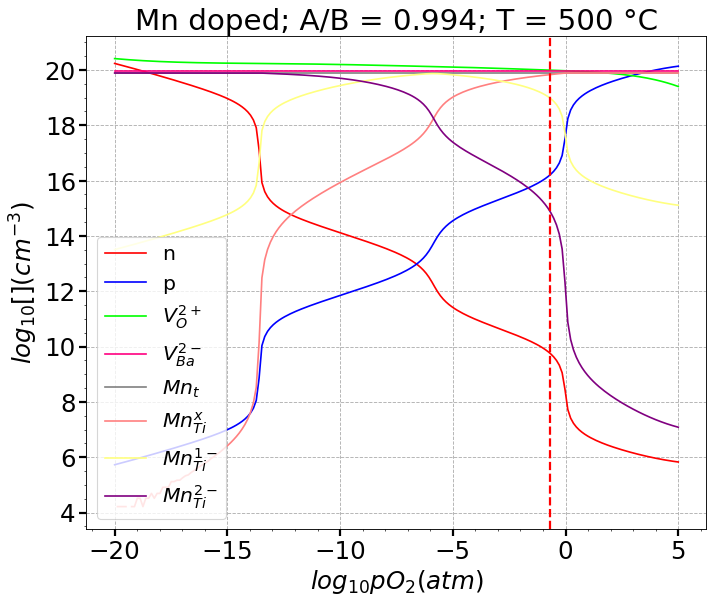

In [11]:
"""
[18] Mn doped & A/B = 0.994 & low T quenched

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = (1 - A/B_ratio)*1.55E22 cm-3 & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 0.994
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_Mn_994e[i] + (CMnt/(KMn43Q/x + 1 + x/KMn32Q))*(1 + 2*x/KMn32Q) - (KiQ/x) - 2*CVO2_Mn_994e[i])
    sol1 = brentq(f,1,1E30)
    
    n_Mn_994q[i] = np.array(sol1).astype(np.float64)
    p_Mn_994q[i] = KiQ/n_Mn_994q[i]
    CVO2_Mn_994q[i] = CVO2_Mn_994e[i]
    CVBa2_Mn_994q[i] = CVBa2_Mn_994e[i]
    CMn1_Mn_994q[i] = CMnt/(KMn43Q/n_Mn_994q[i] + 1 + n_Mn_994q[i]/KMn32Q)
    CMn2_Mn_994q[i] = CMn1_Mn_994q[i]*n_Mn_994q[i]/KMn32Q
    CMn0_Mn_994q[i] = CMnt - CMn1_Mn_994q[i] - CMn2_Mn_994q[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_Mn_994q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_Mn_994q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_Mn_994q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_Mn_994q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_994q+CMn2_Mn_994q+CMn0_Mn_994q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_Mn_994q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_Mn_994q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_Mn_994q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_Mn_994q[154]:.2e}\n'
    f'p = {p_Mn_994q[154]:.2e}\n'
    f'[VO2+] = {CVO2_Mn_994q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_Mn_994q[154]:.2e}\n'
    f'[Mnt] = {CMn1_Mn_994q[154]+CMn2_Mn_994q[154]+CMn0_Mn_994q[154]:.2e}\n'
    f'[Mn0] = {CMn0_Mn_994q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_Mn_994q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_Mn_994q[154]:.2e}'
)

In [12]:
import pandas as pd

# Create a dictionary with the data
data = {'Mn doped': [1, 0.999, 0.994],
        TC: [p_Mn_1000e[154], p_Mn_999e[154], p_Mn_994e[154]],
        TQC: [p_Mn_1000q[154], p_Mn_999q[154], p_Mn_994q[154]]}

# Create a DataFrame (table) from the dictionary
df = pd.DataFrame(data)

# Print the table
print(df.to_string(float_format='%.2e'))

   Mn doped     1150      500
0  1.00e+00 5.49e+18 4.62e+15
1  9.99e-01 5.61e+18 4.76e+15
2  9.94e-01 1.05e+19 1.69e+16
